In [1]:
!pip install requests beautifulsoup4 pandas matplotlib

In [43]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from datetime import datetime

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [44]:
def log_progress(message):

    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    with open("coinmarketcap_bs4_log.txt", "a", encoding="utf-8") as file:
        file.write(f"{timestamp} : {message}\n")

    print(message)

log_progress("Logging Started")

Logging Started


In [45]:
os.makedirs("output", exist_ok=True)
os.makedirs("logs", exist_ok=True)

log_progress("Folders Created")

Folders Created


In [46]:
def scrape_coinmarketcap_bs4(pages=50):

    all_coins = []

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    for page in range(1, pages + 1):

        url = f"https://coinmarketcap.com/?page={page}"

        print(f"Scraping Page {page}...")

        response = requests.get(url, headers=headers)

        soup = BeautifulSoup(response.text, "html.parser")

        rows = soup.find_all("tr")

        for row in rows[1:]:

            cols = row.find_all("td")

            try:
                rank = cols[1].text.strip()
                name = cols[2].text.strip()
                price = cols[3].text.strip()
                marketcap = cols[7].text.strip()

                all_coins.append([
                    rank,
                    name,
                    price,
                    marketcap
                ])

            except:
                continue

        print(f"Total Coins Collected: {len(all_coins)}")

        time.sleep(2)

    return all_coins

In [47]:
coins_data = scrape_coinmarketcap_bs4(pages=50)

print(f"Total Coins Scraped: {len(coins_data)}")

log_progress(f"{len(coins_data)} Records Scraped")

Scraping Page 1...
Total Coins Collected: 15
Scraping Page 2...
Total Coins Collected: 30
Scraping Page 3...
Total Coins Collected: 45
Scraping Page 4...
Total Coins Collected: 60
Scraping Page 5...
Total Coins Collected: 75
Scraping Page 6...
Total Coins Collected: 90
Scraping Page 7...
Total Coins Collected: 105
Scraping Page 8...
Total Coins Collected: 120
Scraping Page 9...
Total Coins Collected: 135
Scraping Page 10...
Total Coins Collected: 150
Scraping Page 11...
Total Coins Collected: 165
Scraping Page 12...
Total Coins Collected: 180
Scraping Page 13...
Total Coins Collected: 195
Scraping Page 14...
Total Coins Collected: 210
Scraping Page 15...
Total Coins Collected: 225
Scraping Page 16...
Total Coins Collected: 240
Scraping Page 17...
Total Coins Collected: 255
Scraping Page 18...
Total Coins Collected: 270
Scraping Page 19...
Total Coins Collected: 285
Scraping Page 20...
Total Coins Collected: 300
Scraping Page 21...
Total Coins Collected: 315
Scraping Page 22...
Total Co

In [48]:
df = pd.DataFrame(coins_data, columns=[
    "Rank",
    "Name",
    "Price",
    "MarketCap"
])

df.head()

,Rank,Name,Price,MarketCap
0,,CoinMarketCap 20 Index DTFCMC20,$162.23,"$16.51M$16,513,086"
1,1,BitcoinBTC,"$80,551.07","$1.61T$1,610,379,704,965"
2,2,EthereumETH,"$2,254.07","$271.55B$271,552,235,567"
3,3,TetherUSDT,$0.9997,"$189.78B$189,780,025,174"
4,4,BNBBNB,$679.38,"$91.43B$91,431,498,638"


In [49]:
print("Before Cleaning:", len(df))

df = df.drop_duplicates()

df = df.replace("", np.nan)

df = df.dropna()

print("After Cleaning:", len(df))

log_progress("Data Cleaned")

Before Cleaning: 750
After Cleaning: 749
Data Cleaned


In [50]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"output/coinmarketcap_bs4_1000plus_{timestamp}.csv"

df.to_csv(filename, index=False)

print("CSV Saved Successfully")

log_progress("CSV Saved")

CSV Saved Successfully
CSV Saved


In [51]:
print(df.info())

display(df.head(10))

display(df.tail(10))

log_progress("Preview Completed")

<class 'pandas.core.frame.DataFrame'>
Index: 749 entries, 1 to 749
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Rank       749 non-null    object
 1   Name       749 non-null    object
 2   Price      749 non-null    object
 3   MarketCap  749 non-null    object
dtypes: object(4)
memory usage: 29.3+ KB
None


,Rank,Name,Price,MarketCap
1,1,BitcoinBTC,"$80,551.07","$1.61T$1,610,379,704,965"
2,2,EthereumETH,"$2,254.07","$271.55B$271,552,235,567"
3,3,TetherUSDT,$0.9997,"$189.78B$189,780,025,174"
4,4,BNBBNB,$679.38,"$91.43B$91,431,498,638"
5,5,XRPXRP,$1.46,"$90.44B$90,435,045,694"
6,6,USDCUSDC,$0.9995,"$76.62B$76,619,997,766"
7,7,SolanaSOL,$90.62,"$52.38B$52,382,121,474"
8,8,TRONTRX,$0.3527,"$33.44B$33,443,209,365"
9,9,DogecoinDOGE,$0.1138,"$17.55B$17,553,350,287"
10,10,HyperliquidHYPE,$45.78,"$11.66B$11,655,543,704"


,Rank,Name,Price,MarketCap
740,4906,capybaraCAPY,$0.061735,"$173,503.26$173,503"
741,4907,Chain GamesCHAIN,$0.004722,--
742,4908,American pepeUSPEPE,$0.091320,"$55,552.51$55,553"
743,4909,Bretta (Brett’s Wife)BRETTA,$0.00008308,"$83,084.39$83,084"
744,4910,RZUSDRZUSD,$0.5046,"$50.47M$50,467,200"
745,4911,Convertible JPY TokenCJPY,$0.004797,--
746,4912,Frax Price IndexFPI,$1.13,"$96.04M$96,037,539"
747,4913,Crypto Deal TokenCDT,$7.97,"$4.39M$4,391,866"
748,4914,Soroosh Smart EcosystemSSE,$0.0002029,"$906,195.65$906,196"
749,4915,Ton RafflesRAFF,$0.03885,"$777,180.39$777,180"


Preview Completed


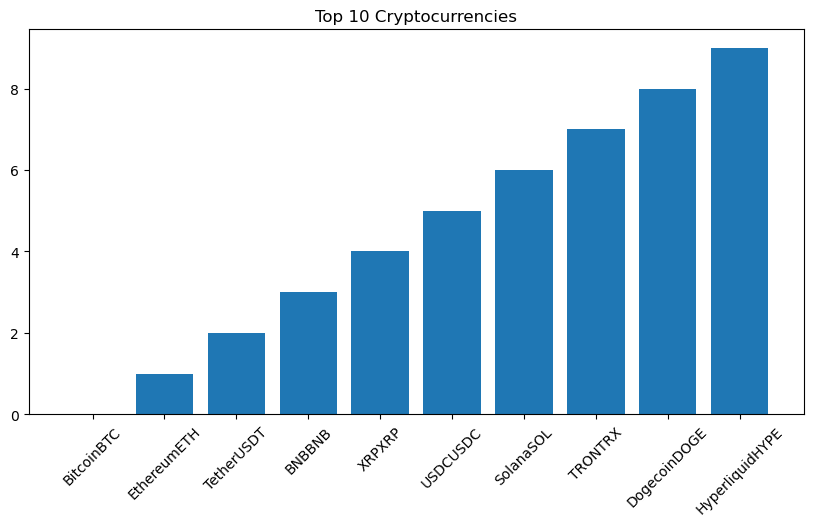

In [52]:
top10 = df.head(10)

plt.figure(figsize=(10,5))

plt.bar(top10["Name"], range(len(top10)))

plt.xticks(rotation=45)

plt.title("Top 10 Cryptocurrencies")

plt.show()